In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def least_square_fitting(X, Y,X_axis,Y_axis,plot,params,Ip):
    # TABLE DATA
    Σx2 = 0
    Σy = 0
    Σxy = 0
    Σx = 0
    count = 0
    Σxylist = []
    Σx2list = []
    Slno = [ ]

    for i in range(len(X)):
        Σx2 += X[i]**2
        Σx2list.append(round(X[i]**2,4))
        Σy += Y[i]
        Σxy += X[i]*Y[i]
        Σxylist.append(round(X[i]*Y[i],4))
        Σx += X[i]
        count += 1
        Slno.append(count)

    # Finding slope and intercept
    fit = np.polyfit(X,Y,1)
    A = fit[0]
    B = fit[1]
    def f(x):
      return A*x + B
    # Error analysis
    error_sum = 0
    for i in range(len(X)):
        error_sum += (Y[i] - f(X[i]))**2
    error_y = (error_sum/ (len(X) - 2))**0.5
    delta = len(X)*Σx2 - Σx**2
    error_slope = error_y * (len(X)/delta)**0.5
    error_intercept = error_y * (Σx2/delta)**0.5
    if params==True:
        #Printing slopes,intercepts and errors
        table2 = PrettyTable()
        table2.title = "Slope, Intercept and Errors"
        table2.add_row(["Slope" , round(A,3) ])
        table2.add_row(["Intercept" , round(B,3) ])
        table2.add_row(["Error in y", round(error_y,3) ])
        table2.add_row(["Delta" , round(delta,5) ])
        table2.add_row(["Error in slope", round(error_slope,5) ])
        table2.add_row(["Error in intercept", round(error_intercept,5) ])
        print(table2)
        print()

    if plot==True:
        #GRAPH PLOT
        plt.xlabel(X_axis)
        plt.ylabel(Y_axis)
        plt.title(X_axis + " vs " + Y_axis + 'at probe current='+str(Ip)+' mA')
        plt.grid()
        plt.scatter(X,Y,label='Data Points',s=20,c='orange')
        fit = np.polyfit(X,Y,1)
        x_fit = np.linspace(min(X),max(X),1000)
        y_fit = fit[1]+fit[0]*x_fit
        plt.plot(x_fit,y_fit,'--', label = f'Least-square fit line : y = ({round(A,3)}±{round(error_slope,3)})x + ({round(B,3)}±{round(error_intercept,3)})')
        plt.legend()
        plt.show()
    if plot==False and params==False:
        return ['Slope = ', A, 'Intercept = ', B, 'Error in slope = ', error_slope, 'Error in intercept = ', error_intercept]


In [5]:

def Magnetoresistance(H, V, Ip, Voff,tick):
    Vcorr1 =[] #mV
    for i in range(len(V)):
        Vcorr1.append(V[i]-Voff)
    R_or = Voff/Ip # ohm
    R1 = np.array(V)/Ip # ohm
    # print(R1)
    del_R1 = []
    for i in range(len(R1)):
        del_R1.append((R1[i]-R_or)/R_or)
    # print(del_R1)
    # polyfitting 
    coeffs = np.polyfit(H, del_R1, 2) # quadratic fit

    # Equation of the fitted curve
    curve_eq = f"y = ({coeffs[0]:.2e})x² + ({coeffs[1]:.2e})x + ({coeffs[2]:.2e})"
    # PLOTTING 
    plt.figure(figsize=(8,6))
    plt.scatter(H, del_R1, marker='o', linestyle='-', color='b',label='Data Points')
    plt.plot(H, np.polyval(coeffs, H), color='r', label='Fitted Curve eq. : '+curve_eq)
    plt.legend()
    plt.title('Magnetoresistance of Bismuth Sample(at probe current='+str(Ip)+' mA)', fontsize=16)
    plt.xlabel('Magnetic Field H (KGauss)', fontsize=14)
    plt.ylabel('Relative Change in Resistance ΔR/R₀', fontsize=14)
    plt.grid(True)
    plt.show()

    Rnew = np.array(V)/Ip # ohm

    del_Rnew = []
    for i in range(len(Rnew)):
        del_Rnew.append((Rnew[i]-R_or)/R_or)
    if tick==True:
        return del_Rnew



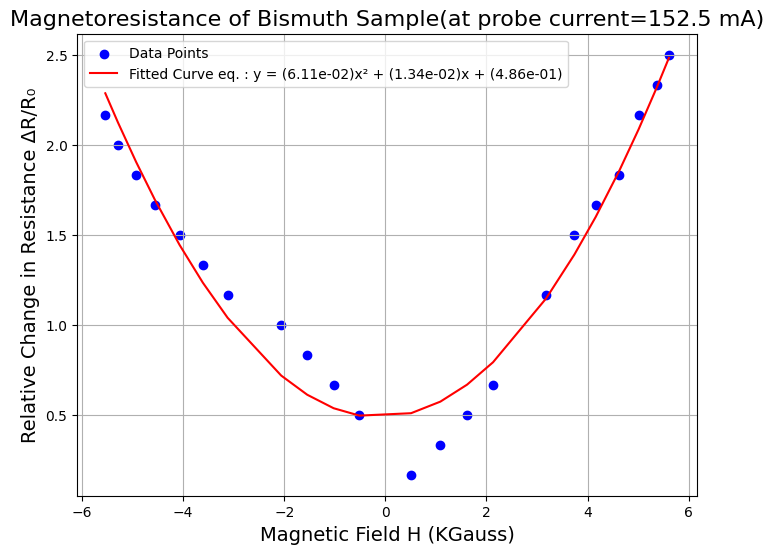

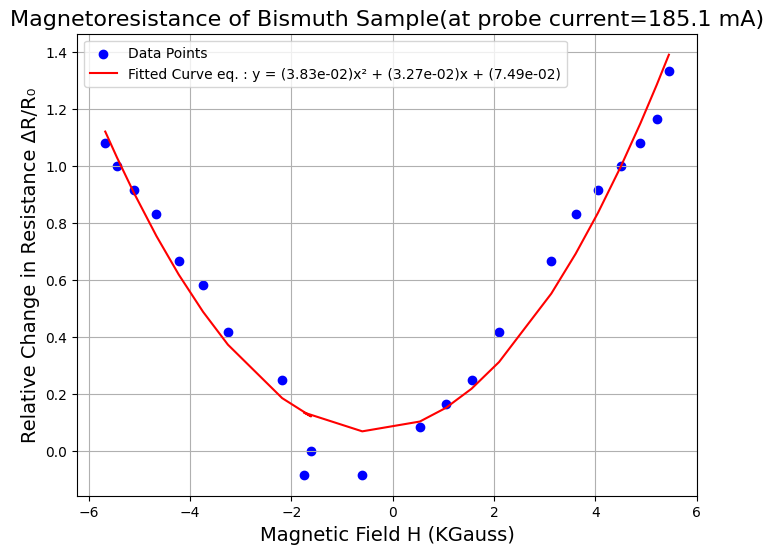

In [6]:
# DATA FOR MAGNETORESISTANCE PLOT FOR Bismuth Sample
Ip1 = 152.5 # mA probe current
Voff1 = 0.006 # mV offset voltage
B1 = [-5.54,-5.29,-4.93,-4.56,-4.07,-3.61,-3.12,-2.06,-1.545,-1.023,-0.513,0.508,1.088,1.616,2.13,3.18,3.74,4.16,4.63,5.01,5.37,5.61]# KGauss
V1 = [0.019,0.018,0.017,0.016,0.015,0.014,0.013,0.012,0.011,0.010,0.009,0.007,0.008,0.009,0.010,0.013,0.015,0.016,0.017,0.019,0.020,0.021] # mV

Ip2 = 185.1 # mA probe current
Voff2 = 0.012 # mV offset voltage
B2 = [-5.67,-5.44,-5.10,-4.66,-4.22,-3.74,-3.25,-2.18,-1.61,-1.75,-0.599,0.536,1.05,1.556,2.10,3.13,3.61,4.05,4.5,4.89,5.21,5.45] # KGauss
V2 = [0.025,0.024,0.023,0.022,0.020,0.019,0.017,0.015,0.012,0.011,0.011,0.013,0.014,0.015,0.017,0.020,0.022,0.023,0.024,0.025,0.026,0.028] # mV

# PLOTS
Magnetoresistance(B1, V1, Ip1, Voff1,False)
Magnetoresistance(B2, V2, Ip2, Voff2,False)

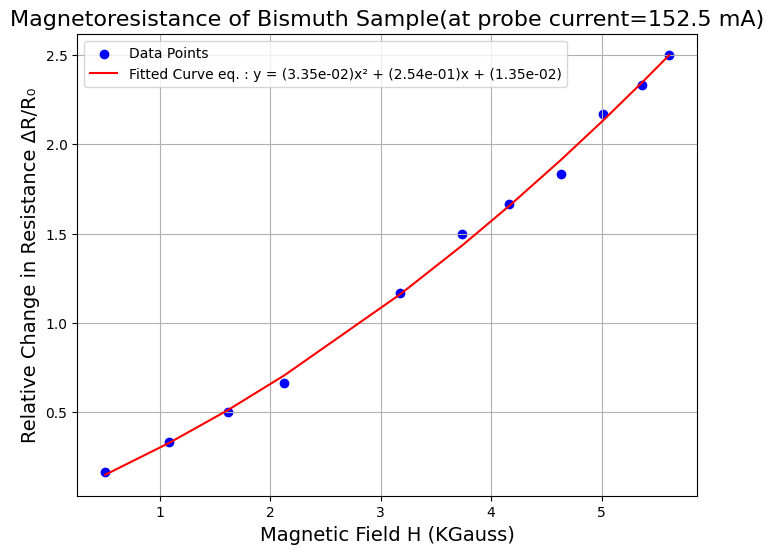

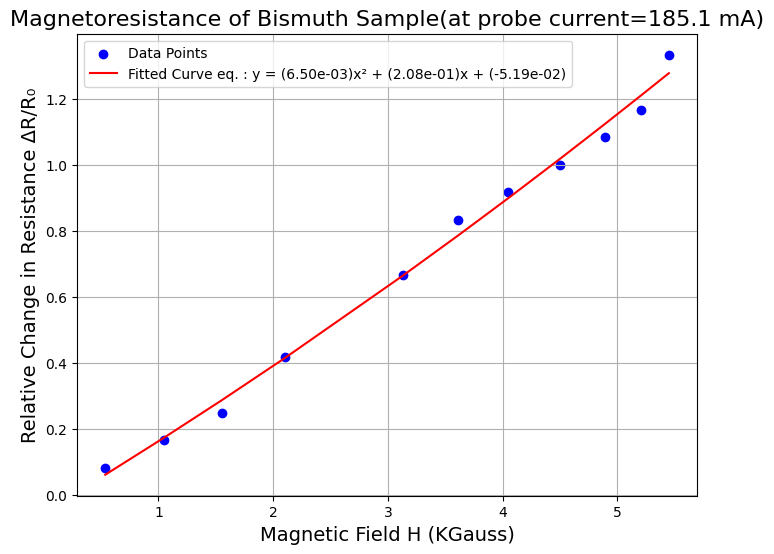

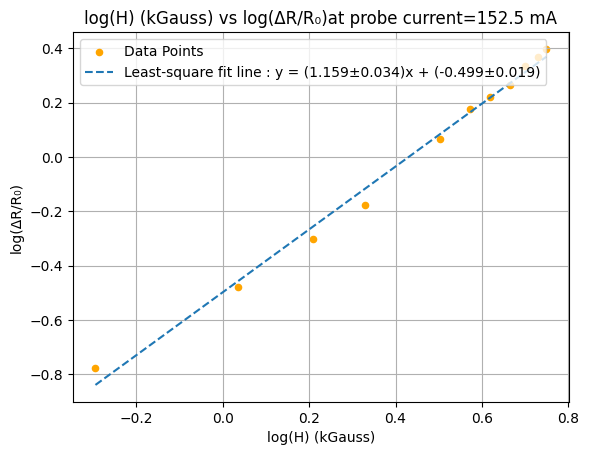

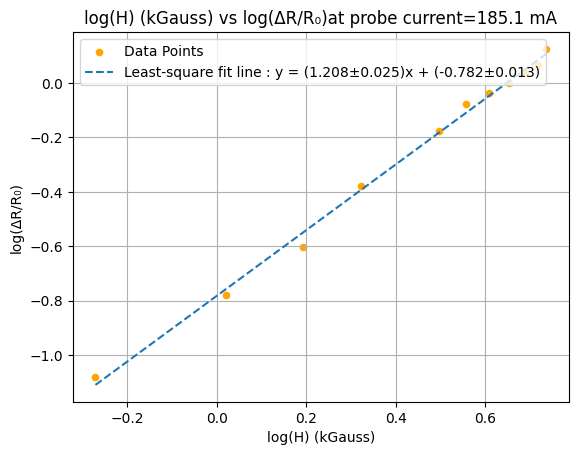

In [7]:
# Only Forward Part analysis
B_f1 = B1[11:]
V_f1 = V1[11:]
B_f2 = B2[11:]
V_f2 = V2[11:]

del_R1 = Magnetoresistance(B_f1, V_f1, Ip1, Voff1,True)
del_R2 = Magnetoresistance(B_f2, V_f2, Ip2, Voff2,True)

# plot of log(del_R/R) vs log(B) 

log_r1 = np.log10(del_R1 )
log_B1 = np.log10(B_f1)
log_r2 = np.log10(del_R2 ) 
log_B2 = np.log10(B_f2)
# print(log_B1)
# print(log_B2)
# print(log_r1)
# print(log_r2)
least_square_fitting(log_B1, log_r1,'log(H) (kGauss)','log(ΔR/R₀)',True,False,Ip1)
least_square_fitting(log_B2, log_r2,'log(H) (kGauss)','log(ΔR/R₀)',True,False,Ip2)

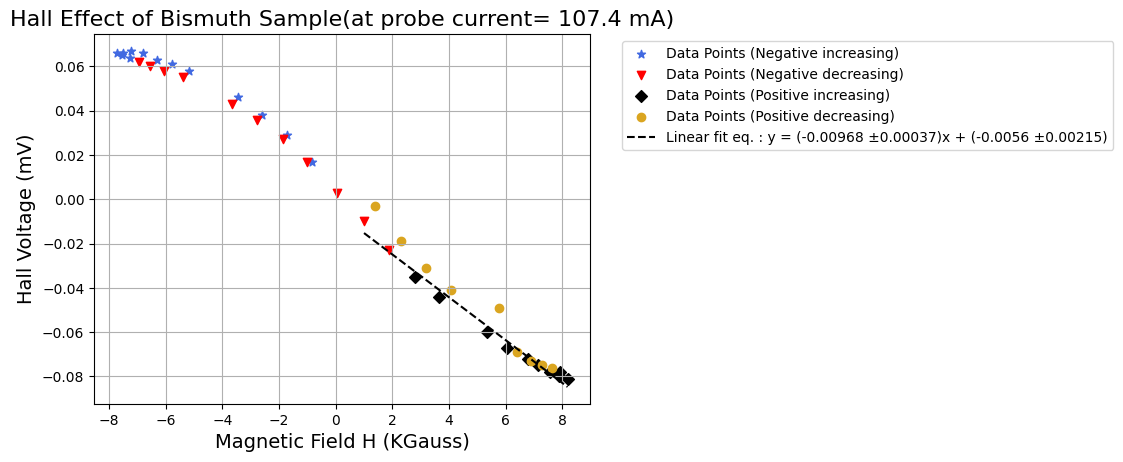

In [8]:
# Hall effect of Bi
B_hall = [-0.825,-1.73,-2.61,-3.46,-5.18,-5.79,-6.32,-6.8,-7.24,-7.5,-7.73,-7.53,-7.27,-6.93,-6.54,-6.05,-5.39,-3.67,-2.78,-1.86,-1.01,0.03,0.998,1.878,2.78,3.64,5.32,6.05,6.78,7.15,7.57,7.88,8.18,7.9,7.62,7.29,6.9,6.41,5.75,4.07,3.2,2.31,1.4] # KGauss
V_hall = [-0.017,-0.029,-0.038,-0.046,-0.058,-0.061,-0.063,-0.066,-0.067,-0.066,-0.066,-0.065,-0.064,-0.062,-0.06,-0.058,-0.055,-0.043,-0.036,-0.027,-0.017,-0.003,0.01,0.023,0.035,0.044,0.06,0.067,0.072,0.075,0.078,0.08,0.081,0.078,0.076,0.075,0.073,0.069,0.049,0.041,0.031,0.019,0.003] # mV
V_hall = [-v for v in V_hall]

plt.scatter(B_hall[:13],V_hall[:13],color='royalblue', marker='*',label='Data Points (Negative increasing)')
plt.scatter(B_hall[13:24],V_hall[13:24],color='red', marker='v',label='Data Points (Negative decreasing)')
plt.scatter(B_hall[24:34],V_hall[24:34],color='black', marker = 'D',label='Data Points (Positive increasing)')
plt.scatter(B_hall[34:],V_hall[34:],color='goldenrod',marker = 'o',label='Data Points (Positive decreasing)')

plt.title('Hall Effect of Bismuth Sample(at probe current= 107.4 mA)', fontsize=16)
plt.xlabel('Magnetic Field H (KGauss)', fontsize=14)
plt.ylabel('Hall Voltage (mV)', fontsize=14)

fit = np.polyfit(B_hall[22:33],V_hall[22:33],1)
Σx2 = 0
Σy = 0
Σxy = 0
Σx = 0
count = 0
Σxylist = []
Σx2list = []
Slno = [ ]
for i in range(len(B_hall[22:33])):
    Σx2 += B_hall[22:33][i]**2
    Σx2list.append(round(B_hall[22:33][i]**2,4))
    Σy += V_hall[22:33][i]
    Σxy += B_hall[22:33][i]*V_hall[22:33][i]
    Σxylist.append(round(B_hall[22:33][i]*V_hall[22:33][i],4))
    Σx += B_hall[22:33][i]
    count += 1
    Slno.append(count)

# Finding slope and intercept
A = fit[0]
B = fit[1]
def f(x):
  return A*x + B
# Error analysis
error_sum = 0
for i in range(len(B_hall[22:33])):
    error_sum += (V_hall[22:33][i] - f(B_hall[22:33][i]))**2
error_y = (error_sum/ (len(B_hall[22:33]) - 2))**0.5
delta = len(B_hall[22:33])*Σx2 - Σx**2
error_slope = error_y * (len(B_hall[22:33])/delta)**0.5
error_intercept = error_y * (Σx2/delta)**0.5

eq_l = f"y = ({round(fit[0],5)} ±{round(error_slope,5)})x + ({round(fit[1],5)} ±{round(error_intercept,5)})"
plt.plot(B_hall[22:33], np.polyval(fit, B_hall[22:33]), color='black', linestyle='--', label=f'Linear fit eq. : {eq_l}')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # make legend outside the plot
plt.show()
